# *Plants* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/180/plants)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last three lines are to customize the style of figures, especially adding a light gray grid and increasing the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

seaborn.set_theme(style="white",
                  rc={"axes.grid": True, "grid.color": '#eaeaf2', "xtick.bottom": True, "ytick.left": True,
                     "figure.figsize": (10, 5)})

The dataset provided on the *UCI* repository has been prepared from data extracted from the [*USDA Plant List of Attributes, Names, Taxonomy, and Symbols (PLANTS)* database](https://plants.sc.egov.usda.gov/).

Each row in the dataset records the distribution of a plant taxon. The first column contains the scientific name of the plant taxon, followed by a list of abbreviations representing the locations, states or territories, where it has been observed.

### Brief summary on taxonomy

*Taxonomy* is the science of organizing biological organisms into groups called *taxa* (plural of *taxon*) and naming them. Taxa are arranged into a hierarchical structure based on evolutionary relationships, and the level of a taxon in this hierarchy is called its *taxonomic rank*. Example taxonomic ranks include *domain*, *kingdom*, *class*, *order*, *genus* (plural *genera*), *species*, *subspecies* and *variety*, from higher to the lower levels.

The basis of naming taxa is the [*binomial nomenclature*](https://en.wikipedia.org/wiki/Binomial_nomenclature), a formal naming systems that assigns a *binomial name*, i.e. a two-term name, to each species.
The first term, referred to as the *generic name*, identifies the genus to which the species belongs while the second term, referred to as the *specific name*, further identifies the species within the genus. Conventionally, scientific names use Latin, are written in italics with the generic name capitalized but not the specific name.

The taxa in this dataset are
- at the rank of genus, in which case their name consists of just one part,
- at the rank of species, in which case their name consists of two parts, or
- at a rank below species, in which case their name has more than two parts.

Furthermore, the dataset also contains *hybrids*, which result from the combination of organisms of different varieties, subspecies, species or genera.
The name of such a hybrid lists the parents, linked using a multiplication sign "×".

## Loading the data

Below we load the data, splitting the taxon name into its parts, and creating one element for each occurrence, that is, for each pair of taxon and location. Using a set to collect these occurrences avoids duplicates, an occurrence of a particular taxon at a given location is counted exactly once.

In [2]:
plants_path = "./plants/plants.data"
collect_occurrences = set()
with open(plants_path, encoding="iso-8859-15") as fp:
    for line in fp:
        parts = line.split(",")
        taxon = parts[0].strip().replace(" x "," ×")
        nparts = taxon.split(" ")
        genus = nparts[0]
        species = " ".join(nparts[:2]) if (len(nparts) > 1 and not nparts[1].startswith("×")) else ""
        variety = taxon if (len(nparts) > 2 or (len(nparts) > 1 and nparts[1].startswith("×"))) else ""
        for p in parts[1:]:
            location = p.strip()
            ## in the dataset, Newfoundland and Labrador are considered separately, respectively as "nf" and "lb"
            ## the following is to group them under "nl"
            # if location in ["nf", "lb"]:
            #     location = "nl"
            ## data issue, Greenland is sometimes denoted "dengl" and sometimes just "gl"
            ## the following is to group under "dengl", consistent with the data information
            if location == "gl":
                location = "dengl"
            collect_occurrences.add((taxon, genus, species, variety, location))

Every occurrence of a taxon can be considered as an occurrence of the corresponding higher-level taxa. Next, we make sure that the data is consistent with respect to this, adding missing occurrences of higher-level taxa, before creating a pandas data frame to store the occurrences.

In [3]:
## Making sure that the species is separately recorded as occurrence whenever one of the varieties occurs
species_only = set([(g,s,l) for (n,g,s,v,l) in collect_occurrences if v == ""])
species_var = set([(g,s,l) for (n,g,s,v,l) in collect_occurrences if v != ""])
missing_occurrences = set([(s, g, s, "", l) for (g,s,l) in species_var.difference(species_only)])
collect_occurrences.update(missing_occurrences)

## Making sure that the genus is separately recorded as occurrence whenever one of the species occurs
genus_only = set([(g,l) for (n,g,s,v,l) in collect_occurrences if (s == "" and v == "")])
genus_sp = set([(g,l) for (n,g,s,v,l) in collect_occurrences if (s != "" or v != "")])
missing_occurrences = set([(g,g,"","",l) for (g,l) in genus_sp.difference(genus_only)])
collect_occurrences.update(missing_occurrences)

plants_dtf = pandas.DataFrame(sorted(collect_occurrences),
                              columns=["taxon", "genus", "species", "variety", "location"])
plants_dtf

,taxon,genus,species,variety,location
0,abelia,abelia,,,fl
1,abelia,abelia,,,nc
2,abelia ×grandiflora,abelia,,abelia ×grandiflora,fl
3,abelia ×grandiflora,abelia,,abelia ×grandiflora,nc
4,abelmoschus,abelmoschus,,,ct
...,...,...,...,...,...
302117,×sorbaronia arsenii,×sorbaronia,×sorbaronia arsenii,,fraspm
302118,×sorbaronia arsenii,×sorbaronia,×sorbaronia arsenii,,nb
302119,×sorbaronia arsenii,×sorbaronia,×sorbaronia arsenii,,ns
302120,×sorbaronia arsenii,×sorbaronia,×sorbaronia arsenii,,qc


## Examining occurrence statistics

Next, we compute some occurrence count statistics.

In [4]:
print("The dataset contains %d distinct taxa, distributed into %d species and %d genera, accross %d locations."
      % (len(plants_dtf["taxon"].unique()), len(plants_dtf["species"].unique()),
         len(plants_dtf["genus"].unique()), len(plants_dtf["location"].unique())))

The dataset contains 34781 distinct taxa, distributed into 22259 species and 3383 genera, accross 69 locations.


First, we focus on *genera*, whose names consists of just one part, i.e. do not contain a space (line 2).
Considering those records, we count the number of times each location appears, which gives us the number of distinct genera observed in each location (line 3).
Vice-versa, we count the number of times each name appears among those records, which gives us the number of distinct genera observed in each location (line 4).

In [5]:
## Records at the genus level
generic_dtf=plants_dtf.loc[~plants_dtf["taxon"].str.contains(" ")]
generic_loc_counts=generic_dtf["location"].value_counts(ascending=False)
generic_name_counts=generic_dtf["taxon"].value_counts(ascending=False)

We do the same while focusing on lower-level taxa, i.e. species, subspecies, varieties and hybrids, whose names contain at least a space.

In [6]:
## Records at least at the species level
specific_dtf=plants_dtf.loc[plants_dtf["taxon"].str.contains(" ")]
specific_loc_counts=specific_dtf["location"].value_counts(ascending=False)
specific_name_counts=specific_dtf["taxon"].value_counts(ascending=False)

We list all unique binomial names, i.e. collect deduplicated genus-species pairs, and count the number of times each genus appears, which gives us the number of distinct species for each genus.

In [7]:
## Number of species per genus
specific_genus_counts=specific_dtf[["genus", "species"]].drop_duplicates()["genus"].value_counts(ascending=False)

Similarly, we list unique names at the level of species or lower, collecting deduplicated pairs of species and taxon names, and count the number of times each species appears. This gives us the number of distinct taxa for each species (including the species itself).

In [8]:
## Number of taxa per species
specific_species_counts=specific_dtf.loc[specific_dtf["species"]!="", ["species", "taxon"]]\
        .drop_duplicates()["species"].value_counts(ascending=False)

Finally, we compute the number of distinct species observed in each location.

In [9]:
## Records at the species level
species_loc_counts=specific_dtf.loc[specific_dtf["species"]!="", ["species", "location"]]\
        .drop_duplicates()["location"].value_counts(ascending=False)

We proceed to visualize these counts.

### Plant diversity of locations

We start with the genus and taxon diversity of locations.

We create two bar plots. Each bar in the left-hand side plot represents a location, showing how many distinct genera occur there, with location sorted from top to bottom by decreasing number of genera. Each bar on the right-hand side plot shows how many distinct taxa occur at the corresponding location.

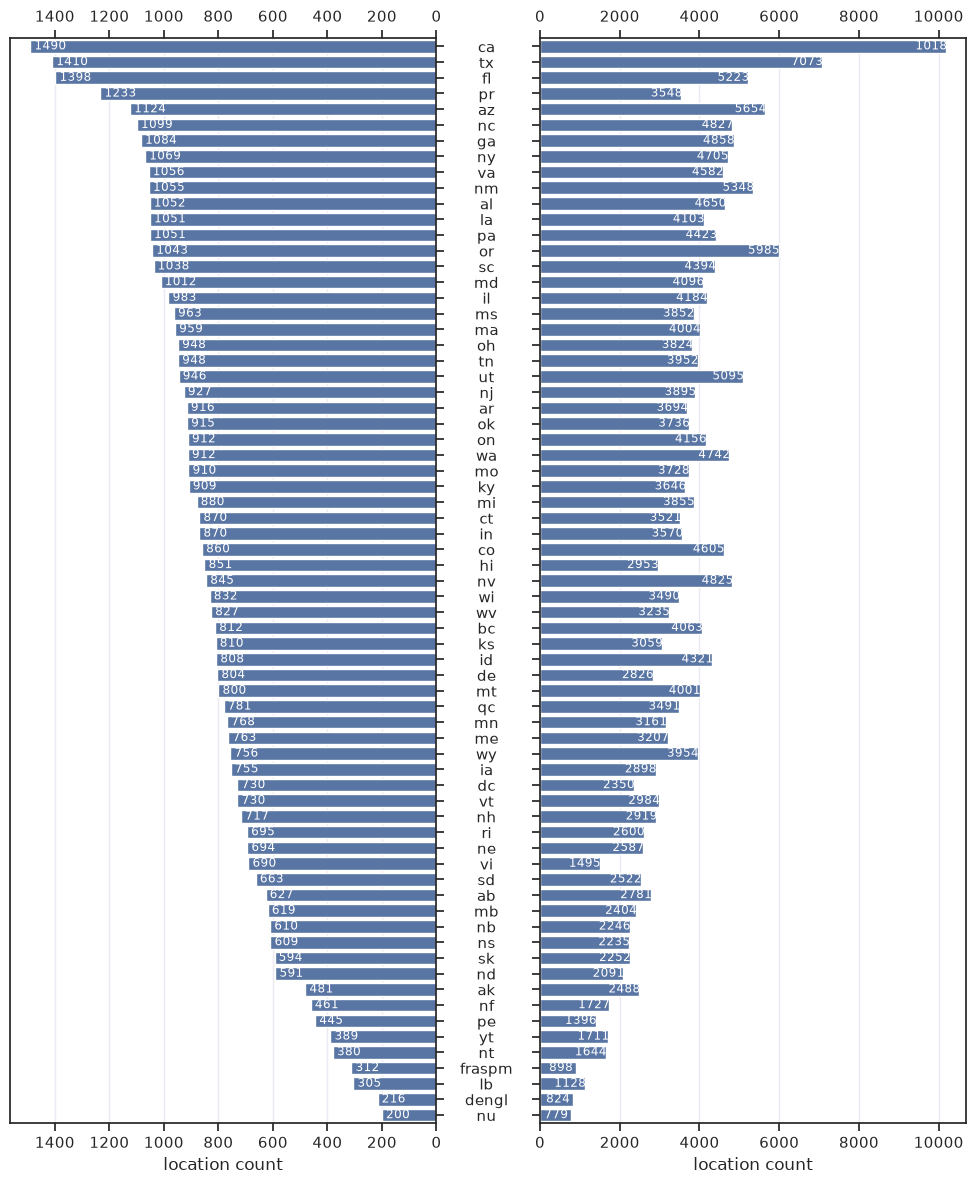

In [10]:
f, axes = plt.subplots(1, 2, sharey=True)
ord_loc = generic_loc_counts.index.to_list()
seaborn.barplot(generic_loc_counts, order=ord_loc, orient="h", ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize="x-small", padding=3, color="#fff");
seaborn.barplot(specific_loc_counts, order=ord_loc, orient="h", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fontsize="x-small", padding=-25, color="#fff", fmt="% 5d");
axes[0].set_ylabel("")
axes[0].set_xlabel("location count")
axes[1].set_xlabel("location count")
axes[0].xaxis.set_inverted(True)
axes[0].set_yticks(axes[0].get_yticks(), axes[0].get_yticklabels(), ha="center");
axes[0].tick_params("y", left=False, right=True, labelleft=False, labelright=True, pad=30)
axes[0].tick_params("x", top=True, bottom=True, labeltop=True, labelbottom=True)
axes[1].tick_params("x", top=True, bottom=True, labeltop=True, labelbottom=True)
f.set_figheight(12)
f.tight_layout()

We can see that the US states of California (ca) and Texas (tx) host the highest numbers of genera and of taxa whereas Nunavut (nu), Canada's northernmost territory, and Greenland (dengl) have the lowest.

We can also see that while there is a correlation between the number of genera and the number of taxa, it is not perfect. Indeed, the bars overall clearly shrink going down the right-hand side plot, but the decrease is not monotone.

Some locations, especially islands such as Puerto Rico (pr), Hawaii (hi) and the Virgin Islands (vi), have a proportionally high diversity of genera compared to the number of taxa, that is, they host a large number of different genera, but a relatively limited number of taxa of each.

### Distribution of taxa

Next we consider how widely distributed a given genus or taxon is, in terms of the number of locations in which it occurs.

Each bar in the plot on the left-hand side represents a genus and records the number of locations where it occurs. Similarly but considering species and infraspecific taxa instead of genera, each bar in the plot on the right-hand side indicates the number of locations where the corresponding taxon occurs.

In both plots, the taxa are sorted decreasingly by their occurrence counts. Since it is not possible to include all taxa, one genus out of a hundred and one species or infraspecific taxon out of a thousand are shown, respectively.

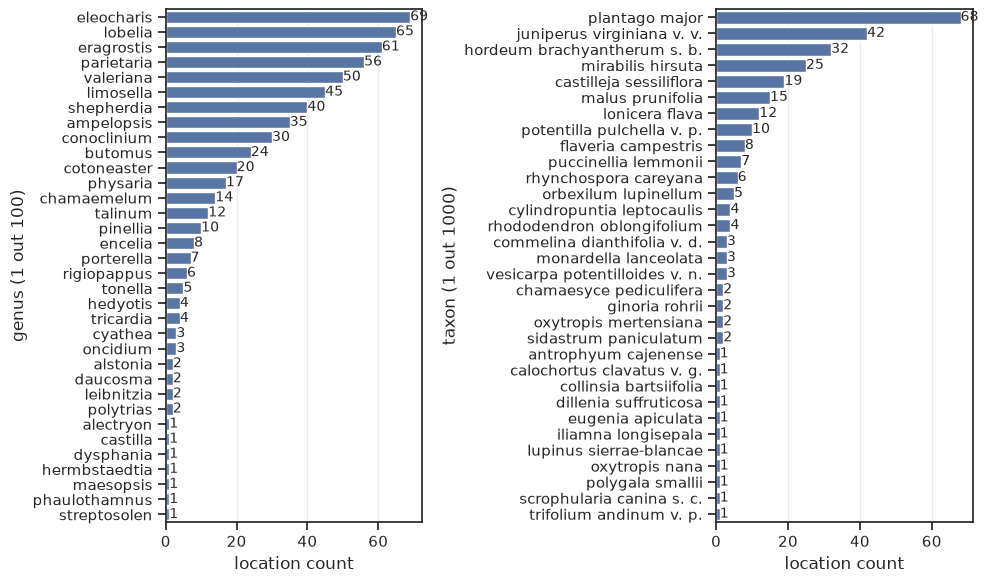

In [11]:
def fmt_short_sp(s):
    parts = s.get_text().split(" ")
    return " ".join(parts[:2]+[p[:1]+"." for p in parts[2:]])

f, axes = plt.subplots(1, 2)
seaborn.barplot(generic_name_counts[::100], orient="h", ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=10);
axes[0].set_ylabel("genus (1 out 100)");
axes[0].set_xlabel("location count");

seaborn.barplot(specific_name_counts[::1000], orient="h", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fontsize=10);
axes[1].set_yticks(axes[1].get_yticks(), [fmt_short_sp(s) for s in axes[1].get_yticklabels()])
axes[1].set_ylabel("taxon (1 out 1000)");
axes[1].set_xlabel("location count");

f.set_figheight(6)
f.tight_layout()

We see that a few taxa are found in all or almost all locations, whereas most taxa are found only in few locations.
The decrease is sharper at the lower taxonomic levels, i.e. in the right-hand side plot, which resembles an exponential distribution.

As a complement, we list the twenty most common taxa in either case, which would correspond to the first twenty bars in the plots above, if we were to display all taxa.

In [12]:
top = 20
dt = pandas.DataFrame([[generic_name_counts.index[i], generic_name_counts.values[i],
                        specific_name_counts.index[i], specific_name_counts.values[i]]
                for i in range(top)], columns=["genus", "genus_location_count", "taxon", "taxon_location_count"])
dt

,genus,genus_location_count,taxon,taxon_location_count
0,eleocharis,69,plantago major,68
1,erigeron,69,poa pratensis,68
2,plantago,69,taraxacum officinale,68
3,polygonum,69,taraxacum officinale ssp. officinale,68
4,agrostis,68,achillea millefolium,67
5,cardamine,68,capsella bursa-pastoris,67
6,carex,68,melilotus officinalis,67
7,chenopodium,68,poa annua,67
8,juncus,68,polygonum arenastrum,67
9,lepidium,68,trifolium pratense,67


The four most common genera occur in all sixty-nine locations.

We see that four of the most common species, namely *Taraxacum officinale*, *Stellaria media*, *Rumex crispus*, *Polygonum convolvulus* and *Cerastium fontanum* appear in almost all locations of the dataset as one of their subspecies ('ssp.') or varieties ('var.').

### Subtaxa diversity of genera and species

Next we consider how diverse the genus and species are, in terms of how many distinct species and infraspecific taxa  in terms of number of subtaxa.

Each bar in the plots on the left-hand side represents a genus and records the number of distinct species of that genus appearing in the dataset.
Similarly, each bar in the plots on the left-hand side represents a species and records the number of distinct taxa of that species appearing in the dataset.

In both plots, the taxa are sorted decreasingly by the corresponding counts, so that genera and species with more subtaxa appear at the top.
Again, we show only every hundredth genus and every thousandth species.

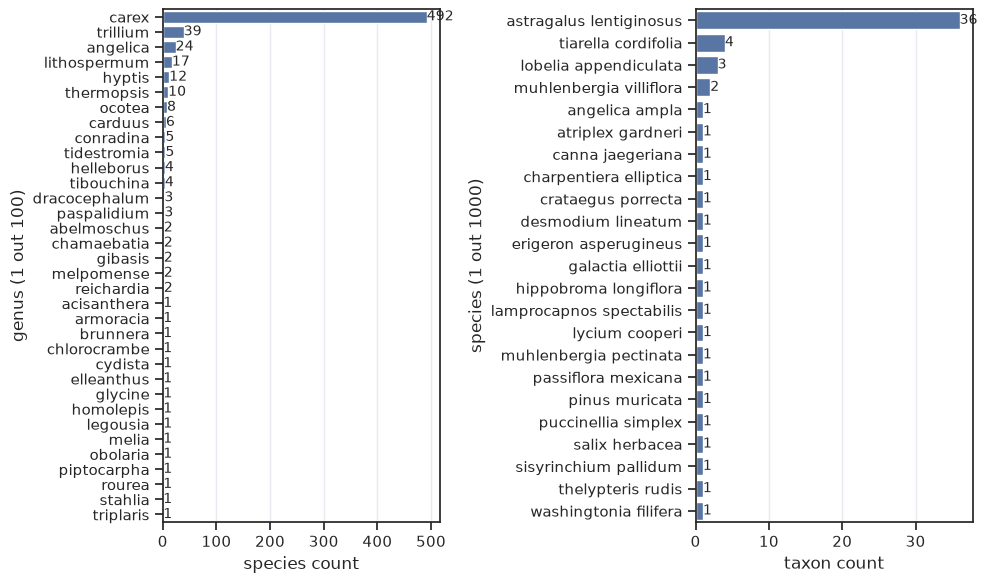

In [13]:
f, axes = plt.subplots(1, 2)
seaborn.barplot(specific_genus_counts[::100], orient="h", ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=10);
axes[0].set_ylabel("genus (1 out 100)");
axes[0].set_xlabel("species count");

seaborn.barplot(specific_species_counts[::1000], orient="h", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fontsize=10);
axes[1].set_ylabel("species (1 out 1000)");
axes[1].set_xlabel("taxon count");

f.set_figheight(6)
f.tight_layout()

The decrease is extremely sharp. Almost five hundred different species of *Carex*, a genus of grass-like plants known for being species-rich, appear in the dataset, whereas the hundredth genus with most species, *Lysimachia*, already only has an order of magnitude fewer species, just thirty-nine.

The vast majority of species do not have distinct subspecies and varieties but appear as a single taxon.

Again, as a complement to these histograms, we list the twenty genera and species with respectively the most species and most subtaxa, which would correspond to the first twenty bars in the plots above, if we were to display all taxa.

In [14]:
top = 20
dt = pandas.DataFrame([[specific_genus_counts.index[i], specific_genus_counts.values[i],
                        specific_species_counts.index[i], specific_species_counts.values[i]]
                for i in range(top)], columns=["genus", "genus_species_count", "species", "species_taxa_count"])
dt

,genus,genus_species_count,species,species_taxa_count
0,carex,492,astragalus lentiginosus,36
1,astragalus,349,eriogonum umbellatum,31
2,penstemon,241,ericameria nauseosa,25
3,rubus,227,sidalcea malviflora,20
4,eriogonum,224,eriogonum nudum,14
5,erigeron,176,hymenopappus filifolius,14
6,crataegus,173,achillea millefolium,13
7,phacelia,158,ericameria parryi,13
8,lupinus,153,eriophyllum lanatum,13
9,cyperus,122,lepidium montanum,13


We note that of the 224 different species of *Eriogonum* that appear in the dataset, two are among the five species richest in subtaxa, namely *Eriogonum umbellatum* and *Eriogonum nudum* with respectively 31 and 14 taxa.

Finally, we look at the relationship between how widely a genus is distributed versus how rich in species it is.

In the scatter plot below, each dot represents a genus, with the position along the horizontal axis representing the number of locations where it occurs and the position along the vertical axis representing the number of distinct species appearing in the data (note the logarithmic scale).
We add some jitter to both dimensions to reduce the overlap and better see the density of points.

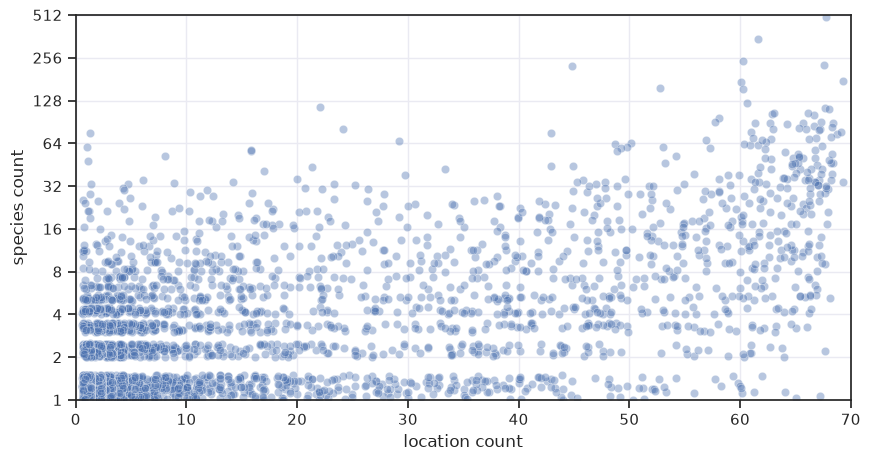

In [15]:
X = pandas.concat([generic_name_counts.rename("locations"), specific_genus_counts.rename("species")], axis=1)
X["logjit_species"] = numpy.log2(X["species"] + numpy.random.uniform(0, .5, X.shape[0]))
X["jit_locations"] = X["locations"] + numpy.random.uniform(-.4, .4, X.shape[0])
ax = seaborn.scatterplot(data=X, x="jit_locations", y="logjit_species", alpha=0.4)
ax.set_ylim([.45, 9]);
ax.set_yticks(ax.get_yticks(), ["%d" % 2**s for s in ax.get_yticks()])
ax.set_ylabel("species count");
ax.set_xlim([0, 70]);
ax.set_xlabel("location count");
# X.loc[(10 < X["locations"]) & (X["locations"]<20) & (10 < X["species"]) & (X["species"]<12)]
#species_loc_counts, specific_species_counts

Most genera occur in only few locations and have a few species, as evident from the crowded lower left corner of the plot. The genera with the highest numbers of distinct species are among the most widely spread across locations. However, some genera have many different species but appear in only very few locations whereas some genera appear in nearly all locations as a single species.

## Mapping the data

Since the dataset involves geographic locations, specifically states and territories, it can be useful to plot on a map.

For this purpose, we use the `geopandas` library (https://geopandas.org/en/stable), which builds on the `pandas` library, adding functionalities to handle geospatial data.

In [16]:
import geopandas

We load the necessary map data from the 'cultural vectors' of the *Natural Earth* dataset, at the intermediate 1:50m scale (https://www.naturalearthdata.com/downloads/50m-cultural-vectors/).

Specifically, we need two subsets:
- [Admin 1 &mdash; States, provinces](https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces.zip) contains states of the USA as well as provinces and territories of Canada,
- [Admin 0 &mdash; Details: subunits](https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_map_subunits.zip) contains dependent territories of Puerto Rico, the US Virgin Islands, Saint Pierre and Miquelon, as well as Greenland.

Just to be sure, after loading, we check that the two geopandas' `GeoDataFrames` have the same `crs` property, that is, that they use the same Coordinate Reference System (CRS).

In [17]:
# nestates_path = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces.zip"
nestates_path = "./geo/ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp"
nestates_gdf = geopandas.read_file(nestates_path)
# nesubunits_path = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_map_subunits.zip"
nesubunits_path = "./geo/ne_50m_admin_0_map_subunits/ne_50m_admin_0_map_subunits.shp"
nesubunits_gdf = geopandas.read_file(nesubunits_path)
assert(nesubunits_gdf.crs == nestates_gdf.crs)

We collect the rows that we need from the two subsets, representing states of the USA as well as provinces and territories of Canada, on one hand, and the other four territories, on the other hand, for which we add abbreviations.

In [18]:
states_columns = ["iso_3166_2", "iso_a2", "iso_3166_2", "name", "geometry"]
X = numpy.vstack([
    nestates_gdf.loc[nestates_gdf["iso_a2"]=="CA",states_columns].values,
    nestates_gdf.loc[nestates_gdf["iso_a2"]=="US",states_columns].values,
    numpy.hstack([numpy.array([["-PR", "US", "US-PR"],
                               ["-VI", "US", "US-VI"],
                               ["-FRASPM", "FRA", "FRA-SPM"],
                               ["-DENGL", "DEN", "DEN-GL"]]),
                numpy.vstack([
        nesubunits_gdf.loc[nesubunits_gdf["ADMIN"]=="Puerto Rico",["ADMIN","geometry"]].values,
        nesubunits_gdf.loc[nesubunits_gdf["ADMIN"]=="United States Virgin Islands",["ADMIN","geometry"]].values,
        nesubunits_gdf.loc[nesubunits_gdf["ADMIN"].str.startswith("Saint Pierre"),["ADMIN","geometry"]].values,
        nesubunits_gdf.loc[nesubunits_gdf["ADMIN"]=="Greenland",["ADMIN","geometry"]].values
                ])
        ])
    ])

If our plants data does not contain the location 'nl', for the Canadian province 'Newfoundland and Labrador', that means that we kept Newfoundland and Labrador separate, as they are provided in the plants dataset, respectively abbreviated 'nf' and 'lb'.

In this case, we need to split the map of the Canadian province accordingly. The two largest polygons in the corresponding geometry stored as the last column of `X` represent Labrador and Newfoundland, respectively. We assign the smaller polygons, representing smaller islands of the province based on their latitude.

In [19]:
if "nl" not in generic_loc_counts.index:
    ### separate geometry of Newfoundland and Labrador
    from shapely import MultiPolygon
    id_nl = numpy.where(X[:,0] == "CA-NL")[0][0]
    nl_geoms = X[id_nl, -1].geoms
    o = sorted(range(len(nl_geoms)), key=lambda i: nl_geoms[i].area, reverse=True)
    ## Labrador is the largest, Newfoundland the second largest
    polys= {"lb": [nl_geoms[o[0]]], "nf": [nl_geoms[o[1]]]}
    ## Determine latitude cut-point
    cutpoint_y = (polys["lb"][0].bounds[1]+polys["nf"][0].bounds[3])/2
    for i in o[2:]:
        if nl_geoms[i].centroid.y > cutpoint_y:
            ## everything north of the cut-point goes to Labrador
            polys["lb"].append(nl_geoms[i])
        else:
            ## everything south of the cut-point goes to Newfoundland
            polys["nf"].append(nl_geoms[i])

    X = numpy.insert(X, id_nl, ["CA-NF", "CA", "CA-NF", "Newfoundland", MultiPolygon(polys["nf"])], axis=0)
    X[id_nl+1, :] = ["CA-LB", "CA", "CA-LB", "Labrador", MultiPolygon(polys["lb"])]

We create a GeoDataFrame to store the geospatial data for the locations of the plants dataset.

ISO 3166-2 codes are codes of the form 'XX-YY' identifying states or provinces of countries, where 'XX' is the code of the country and 'YY' identifies the province or state within the country.

Usefully, the lowercase second part of these codes matches the abbreviations used to identify locations in our plants dataset. So we collect them and use them to index the geospatial data.

In [20]:
idx = [x.split("-")[1].lower() for x in X[:,0]]
plants_gdf = geopandas.GeoDataFrame(X[:,1:],
                                index=idx, columns=["iso_a2", "iso_3166_2", "name", "geometry"],
                                crs=nestates_gdf.crs)

For each location, we add the counts of occurring genera, species and taxa.

In [21]:
idx = plants_gdf.index
plants_gdf["genus_count"] = [generic_loc_counts.loc[i] for i in idx]
plants_gdf["species_count"] = [species_loc_counts.loc[i] for i in idx]
plants_gdf["taxon_count"] = [specific_loc_counts.loc[i] for i in idx]

We also compute a rough estimate of the surface area of each location in the dataset, as the sum of the areas of the polygons representing its geometry.

To do this, we need to project the geographic coordinates in a reference system that preserves area. That is, we need to use an [equal-area map projection](https://en.wikipedia.org/wiki/Equal-area_projection), such as the world sinusoidal projection, identified as `esri:54008`.

In [22]:
plants_gdf["surface_area"] = plants_gdf.to_crs("esri:54008").geometry.area
plants_gdf

,iso_a2,iso_3166_2,name,geometry,genus_count,species_count,taxon_count,surface_area
ab,CA,CA-AB,Alberta,"POLYGON ((-109.99943 48.99308, -110.3213 48.99...",627,1925,2781,6.637856e+11
bc,CA,CA-BC,British Columbia,"MULTIPOLYGON (((-120.00001 60.00109, -120.0000...",812,2854,4063,9.426869e+11
mb,CA,CA-MB,Manitoba,"POLYGON ((-88.9485 56.85131, -89.20522 56.6948...",619,1731,2404,6.523564e+11
nb,CA,CA-NB,New Brunswick,"MULTIPOLYGON (((-64.03094 46.01267, -64.05135 ...",610,1658,2246,7.261483e+10
nf,CA,CA-NF,Newfoundland,"MULTIPOLYGON (((-55.45873 51.53655, -55.53245 ...",461,1223,1727,1.092551e+11
...,...,...,...,...,...,...,...,...
wy,US,US-WY,Wyoming,"POLYGON ((-104.02166 41.00086, -104.33572 41.0...",756,2650,3954,2.543875e+11
pr,US,US-PR,Puerto Rico,"MULTIPOLYGON (((-66.12939 18.44492, -66.09849 ...",1233,3221,3548,8.915122e+09
vi,US,US-VI,United States Virgin Islands,"MULTIPOLYGON (((-64.84502 18.33008, -64.91997 ...",690,1345,1495,3.148035e+08
fraspm,FRA,FRA-SPM,Saint Pierre and Miquelon,"MULTIPOLYGON (((-56.15073 46.7624, -56.17168 4...",312,665,898,2.057731e+08


We write a function for plotting geospatial data...

In [23]:
def make_plot(gdf, title, plot_parameters, crs, label_element=None, shift={},
              fontsize="xx-small", legend=True, save_path=None, ax=None, figsize=(16,10)):
    """Plots geospatial data.

        Parameters
        ----------
        gdf: geopandas.GeoDataFrame
            The GeoDataFrame containing the feature values and the geometry of the objects to plot
        title: str
            The title of the plot
        plot_parameters: dict
            Parameters for plotting, especially "column", "cmap", "vmin" and "vmax" must be specified
        crs: pyproj.CRS
            The Coordinate Reference System (CRS) code of the projection to use for the map
        label_element: callable
            A function to prepare the annotation text for a given object, if None no annotations are generated
        shift: dict
            Shifts for the annotation labels, see `annotate_element` function
        fontsize: str or int
            The specification of fontsize for the annotations
        legend: bool
            Whether to add a legend (colorbar) to the plot
        save_path: str
            A filepath where to save the generated figure, works only if ax is None
        ax: pyplot.Axes
            The axes in which to plot the data, if None a new figure and subplot are created
        figsize: 2-tuple of floats
            Figure dimension (width, height) in inches
    """

    fig = None
    if ax is None:
        fig = plt.figure(1, figsize=figsize)
        ax = fig.add_subplot()

    # Plotting main map
    main_pgdf = gdf.drop(plot_parameters.get("drop_ids", plot_parameters.get("inset_ids", []))).to_crs(crs)

    if label_element is not None:
        main_plot_parameters = {"no_annot": plot_parameters.get("inset_ids")}
        main_plot_parameters.update(plot_parameters)
        main_pgdf.apply(lambda elem: annotate_element(ax, elem, label_element,
                                                   main_plot_parameters, shift, fontsize), axis=1);
    main_pgdf.boundary.plot(ax=ax, color="black", linewidth=.4, alpha=0.5);
    legend_kwds = {}
    if legend:
        ax_cb = ax.inset_axes([0.25, 0.01, 0.75, 0.02])
        legend_kwds={"cax": ax_cb, "orientation": "horizontal"}
    main_pgdf.plot(ax=ax, column=plot_parameters["column"],
                  vmin=plot_parameters["vmin"], vmax=plot_parameters["vmax"],
                  cmap=plot_parameters["cmap"], legend=legend, legend_kwds=legend_kwds,
                  edgecolor="black", linewidth=0.4)

    # Plotting inset map
    if "inset_ids" in plot_parameters:
        inset_pgdf = gdf.loc[plot_parameters["inset_ids"]].to_crs(plot_parameters.get("inset_crs", crs))

        inset_ax = ax.inset_axes(plot_parameters.get("inset_bounds", [0.01, 0.01, 0.2, 0.1]))

        if label_element is not None:
            inset_pgdf.apply(lambda elem: annotate_element(inset_ax, elem, label_element,
                                                   plot_parameters, shift, fontsize, alpha=0.8), axis=1);
        inset_pgdf.boundary.plot(ax=inset_ax, color="black", linewidth=.4, alpha=0.5);
        inset_pgdf.plot(ax=inset_ax, column=plot_parameters["column"],
                         vmin=plot_parameters["vmin"], vmax=plot_parameters["vmax"],
                         cmap=plot_parameters["cmap"], legend=False,
                         edgecolor="black", linewidth=0.4)
        if "inset_bbox_buffer" in plot_parameters:
            # inset_center_bounds = inset_pgdf["geometry"].centroid.bounds.mean(axis=0)
            inset_center_bounds = inset_pgdf.iloc[0]["geometry"].centroid.bounds
            inset_ax.set_xlim([inset_center_bounds[0]+plot_parameters["inset_bbox_buffer"][0],
                               inset_center_bounds[2]+plot_parameters["inset_bbox_buffer"][2]])
            inset_ax.set_ylim([inset_center_bounds[1]+plot_parameters["inset_bbox_buffer"][1],
                               inset_center_bounds[3]+plot_parameters["inset_bbox_buffer"][3]])
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

    ax.set_title(title)

    ax.axis("off");

    if save_path is not None and fig is not None:
        fig.savefig(save_path)

    return ax

...a function for annotating the elements of our plots...

In [24]:
def annotate_element(ax, elem, label_element, plot_parameters={}, shift={},
                     fontsize="xx-small", alpha=0.6, wa_alpha=0.8):
    """Prepare the annotation for an element.

        Parameters
        ----------
        ax: pyplot.Axes
            The axes in which to plot the data
        elem:
            The object to annotate
        label_element: callable
            A function to prepare the annotation text for a given object, if None no annotations are generated
        plot_parameters : dict
            Parameters for plotting, especially "column", "palette", "vmin" and "vmax" must be specified
            Optional parameters include
                "no_annot" (list of object indices) to list objects that should not be annotated
                "only_true" (bool) to only annotate objects whose value is strictly positive
                "count" (bool) to include the value as an integer in the label text
        shift: dict
            Shifts for the annotation labels, keys are object indices,
            values are tuples (x,y[,a]) where x and y are the amount by which to shift
            the annotation label of the object along the x and y coordinates.
            If a triple is provided, an arrow is added pointing from the label to the annotation position
        fontsize: str or int
            The specification of fontsize for the annotations
        alpha: float
            Opacity of the annotation box
        wa_alpha: float
            Opacity of the annotation box for annotations with an arrow
    """

    if plot_parameters.get("no_annot") is None or elem.name not in plot_parameters.get("no_annot"):
        text = label_element(elem, plot_parameters)
        if text is None:
            return

        fact_xytext = 7
        vfrac = (plot_parameters["vmax"] - elem[plot_parameters["column"]])/(
            plot_parameters["vmax"] - plot_parameters["vmin"])
        txt_color = plot_parameters["palette"](0.95 if vfrac > 0.45 else 0.1)
        box_color = plot_parameters["palette"](1-vfrac)

        eshift = shift.get(elem.name, shift.get(None, (0,-5)))
        xytext = eshift[:2]
        arrowprops = None

        if len(eshift) == 3:
            alpha = wa_alpha
            arrowprops = dict(arrowstyle="->", linewidth=.5, edgecolor="black")

        ax.annotate(text=text,
                xy=elem.geometry.centroid.coords[0],
                xytext=(xytext[0]/fact_xytext,xytext[1]/fact_xytext), textcoords="offset fontsize",#points",
                ha="center", fontsize=fontsize, color=txt_color,
                bbox=dict(boxstyle="round", pad=.1, lw=0, fc=box_color, alpha=alpha),
                arrowprops=arrowprops)

...and two functions for generating the text of labels with which to annotate elements in our plots.

Function `label_element_long` returns a label including the full name and abbreviation of the location, whereas the labels returned by `label_element_short` include just the abbreviation.

In [25]:
def label_element_long(elem, plot_parameters={}):
    if not plot_parameters.get("only_true", False) or elem[plot_parameters["column"]] > 0:
        if plot_parameters.get("count", True):
            return "%s\n(%s%d)" % (elem["name"].replace(" and ", "\nand "),
                                "%s: " % elem.name if plot_parameters.get("abbr", True) else "",
                                elem[plot_parameters["column"]])
        else:
            return "%s%s" % (elem["name"].replace(" and ", "\nand "),
                                "\n(%s)" % elem.name if plot_parameters.get("abbr", True) else "")

def label_element_short(elem, plot_parameters={}):
    if not plot_parameters.get("only_true", False) or elem[plot_parameters["column"]] > 0:
        if plot_parameters.get("count", False):
            return "%s%d" % ("%s: " % elem.name if plot_parameters.get("abbr", True) else "",
                    elem[plot_parameters["column"]])
        else:
            return elem.name if plot_parameters.get("abbr", True) else " "

We define common parameters for our maps, such as choosing the coordinate reference system, setting the shifts to adjust the position of the labels, and setting the parameters for the inset map that we use for plotting Hawaii.

In [26]:
# crs_main = "EPSG:4326" # WGS84 Latitude/Longitude, used in GPS
# crs_main = "EPSG:3395" # Spherical Mercator. Google Maps, OpenStreetMap, Bing Maps
# crs_main = "EPSG:3857" # WGS84 Pseudo-Mercator
# crs_main = "EPSG:32633" # UTM Zones (North) -- (Universal Transverse Mercator)
# crs_main = "EPSG:23328" # NAD83(2011) / ICS83-Robinson (ftUS)
# crs_main = "+proj=ortho +lat_0=45.00 +lon_0=-55.0000"
# crs_main = "+proj=natearth"
# crs_main = "ESRI:54030"
# crs_main = 10598 # WGS_1984_GLANCE_North_America
# crs_main = 27705 # WGS_1984_Equi7_North_America
crs_main = 3347 # NAD_1983_Statistics_Canada_Lambert

shift = {
        "ab": (-2,-8), "nb": (-10,8), "ns": (10,-8), "nt": (-2,-25), "sk": (-2,-25),
        "nu": (-15,-35), "lb": (8, -8),
        "fraspm": (50, 0, 1), "pe": (70, 2, 1),
        "al": (5,-22), "ca": (0,-20), "fl": (8,-10), "ga": (-2,-5), "hi": (30,7),
        "id": (0,-12), "il": (-0,-6), "in": (0,12), "la": (-5,-10), "mi": (0,8),
        "mn": (6,1), "mo": (0,-9), "nd": (-6,-5), "nm": (0,-15), "ny": (-10,-5),
        "oh": (0,-13), "pa": (-5,-5), "sd": (0,-5), "tn": (-5,-8), "ut": (0,-10), "wi": (0,-7),
        "ct": (-35,38,1), "dc": (90,-23,1), "de": (85,-3,1), "ma": (120,-5,1), "md": (148,-16,1),
        "nc": (42,-31,1), "nh": (65,-6,1), "nj": (33,-5,1), "ri": (64,-12,1), "sc": (32,-34,1),
        "va": (89,-47,1), "vt": (98,13,1), "wv": (108,-35,1),
        "vi": (-20,15,1), "pr": (-50,0,1)
        }

fshrt = 1/2.5
shift_short = {None: (0,-2),
        "nu": (-4*fshrt,-18), "nt": (-12*fshrt,-10),
        "fraspm": (50*fshrt, -2, 1), "pe": (50*fshrt, -2, 1),
        "fl": (8*fshrt,-5), "hi": (35*fshrt,6), "va": (8*fshrt,-2),
        "ct": (50*fshrt,-14,1), "dc": (50*fshrt,-22,1), "de": (70*fshrt,-16,1),
        "ma": (100*fshrt,-9,1), "md": (90*fshrt,-26,1),
        "nh": (65*fshrt,-6,1), "nj": (25*fshrt,-6,1), "ri": (64*fshrt,-12,1), "vt": (80*fshrt,3,1),
        "vi": (-20*fshrt,15,1), "pr": (-50*fshrt,0,1)
        }


inset_parameters = {
    "inset_ids": ["hi"],
    "inset_bbox_buffer": [-5, -2.5, 5, 2.5],
    "inset_crs": "EPSG:4326",
}

Now we are ready to use these tools to plot the data on a map.

### Surface area

We start by creating a map to show the relative surface areas of the location. We take the square root of the areas (to get a finer resolution among the smaller values), and scale the values to range between 0 and 1000, i.e. per mille. We use a colormap such that the smaller areas are depicted in light yellow whereas the larger areas are depicted in dark brown.

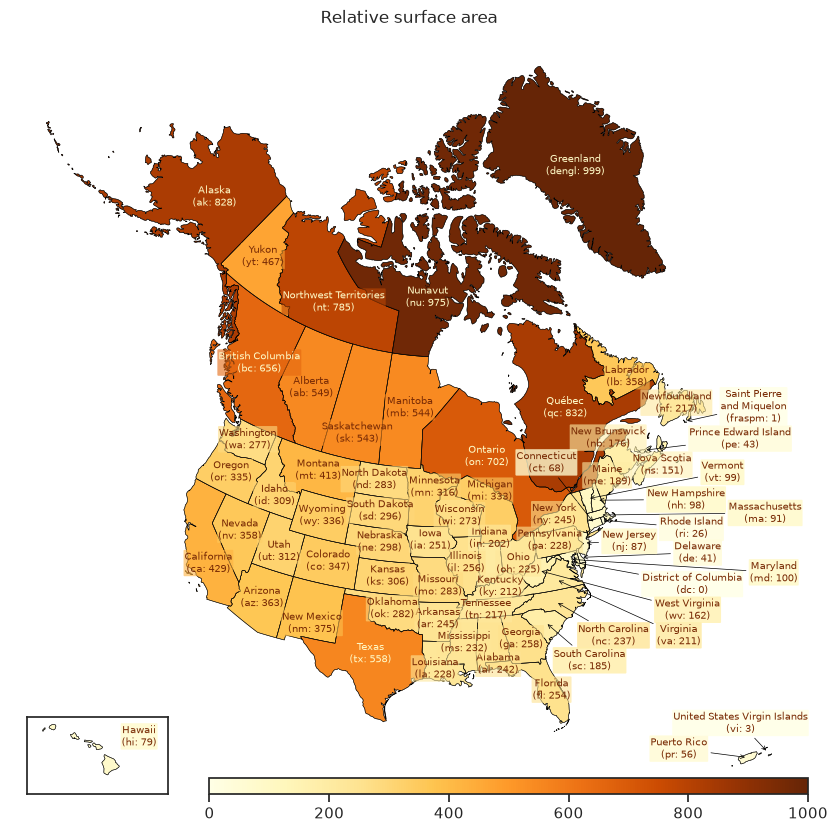

In [27]:
sqrtarea = numpy.sqrt(plants_gdf["surface_area"])
min_sqrtarea, max_sqrtarea = (numpy.floor(sqrtarea.min()), numpy.ceil(sqrtarea.max()))
plants_gdf["relative_sqrtarea"] = 1000*(sqrtarea-min_sqrtarea)/(max_sqrtarea-min_sqrtarea)

pp_area = {"column": "relative_sqrtarea",
    "cmap": "YlOrBr",
    "palette": seaborn.color_palette("YlOrBr", as_cmap=True),
    "vmin": 0,
    "vmax": 1000
    }
pp_area.update(inset_parameters)

make_plot(plants_gdf, "Relative surface area", pp_area, crs_main, label_element_long, shift);

We see that the dataset contains locations with very different surface areas, from tiny islands of Saint Pierre and Miquelon to the great Greenland, from the District of Columbia to Texas in mainland USA, and including the vast provinces and territories of Canada.

### Genus diversity

Next, we look at the diversity of plants found in each location, in terms of the number of distinct genera that have been observed. The locations with highest diversity are depicted in dark green.

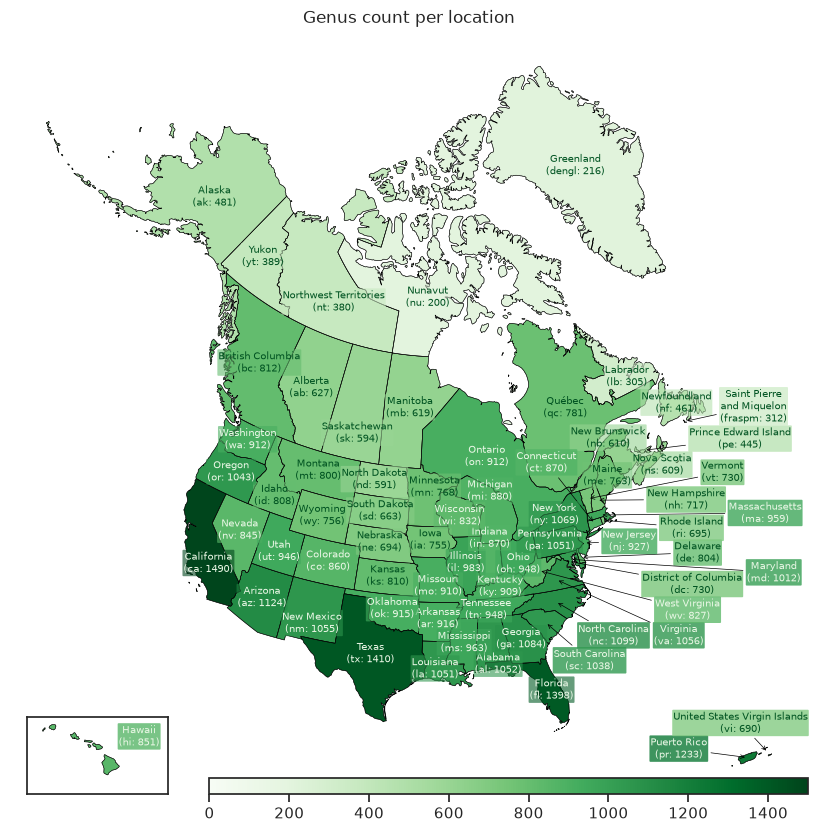

In [28]:
pp_count = {"column": "genus_count",
    "cmap": "Greens",
    "palette": seaborn.color_palette("Greens", as_cmap=True),
    "vmin": 0,
    "vmax": 1500
    }
pp_count.update(inset_parameters)

make_plot(plants_gdf, "Genus count per location", pp_count, crs_main, label_element_long, shift);

We see that the locations with highest genus diversity, such as California, Texas, Florida and Puerto Rico, are southern locations with a coast, where well above a thousand different genera are found. On the other hand northern locations like Nunavut and Greenland have some of the lowest diversity, with only a couple of hundred different genera.

### Occurrences of *Eucephalus*

Next, we focus on a particular genus and plot its occurrences. Specifically, locations where *Eucephalus* has been observed are depicted in green.

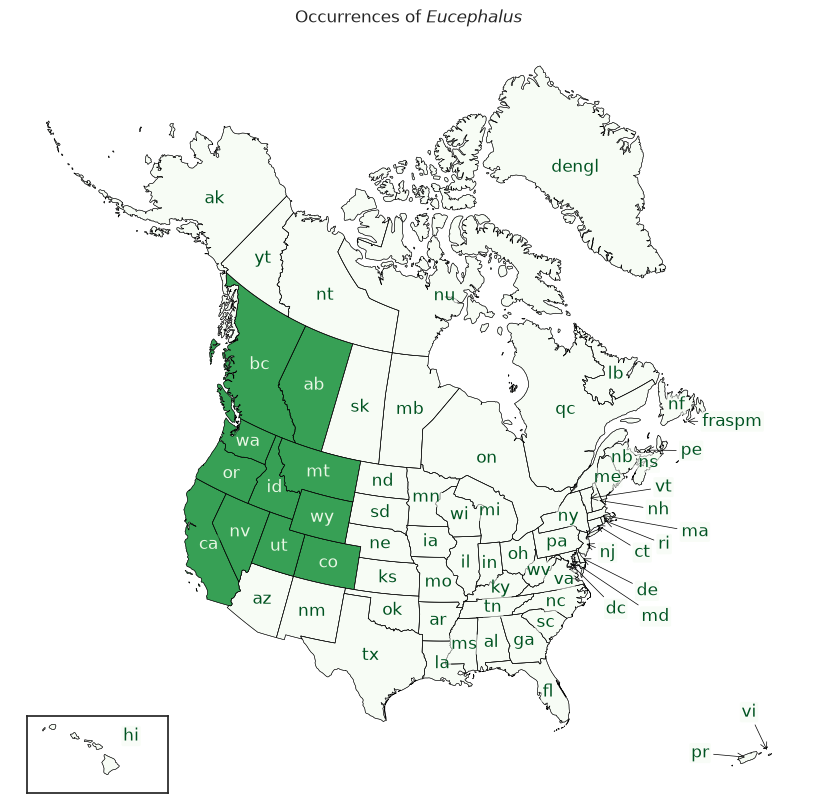

In [29]:
#genus = "cistanthe"
genus = "eucephalus"
#genus = "fagus"
#genus = "polygonella"
column_occ = "occ_"+genus
locations = plants_dtf.loc[plants_dtf["taxon"]==genus, "location"].unique()
plants_gdf[column_occ] = 0
plants_gdf.loc[locations, column_occ] = 1

pp_occ = {"column": column_occ,
    "cmap": "Greens",
    "palette": seaborn.color_palette("Greens", as_cmap=True),
    "vmin": 0,
    "vmax": 1.5
    }
pp_occ.update(inset_parameters)

make_plot(plants_gdf, f"Occurrences of ${genus.capitalize()}$", pp_occ, crs_main,
          label_element_short, shift_short, fontsize=12, legend=False);

We see that *Eucephalus* is found in eastern states of mainland USA as well as south-east provinces of Canada, forming a contiguous area.

### Occurrences of *Picea*

Moving from small flowering plants to larger trees, we focus on *Picea*, or spruce.

On the left-hand side we show a map of occurrences of *Picea*. On the right-hand side show the number of different *Picea* taxa recorded in each of the location where it occurs, and depict location with a higher diversity in darker shades of green.

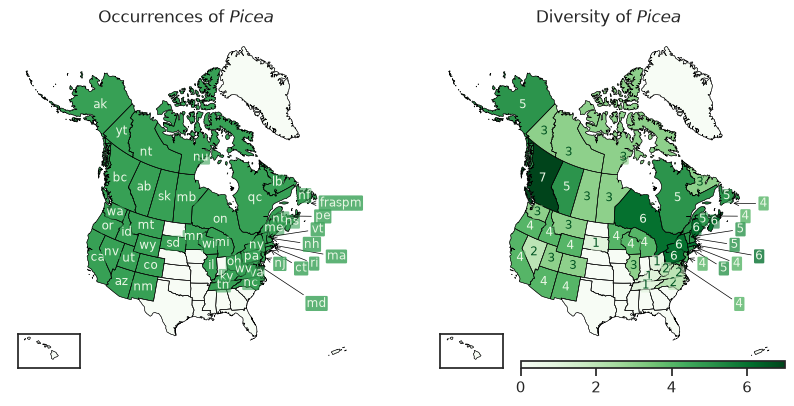

In [30]:
genus = "picea"

f, axes = plt.subplots(1, 2)

column_occ = "occ_"+genus
locations = plants_dtf.loc[(plants_dtf["genus"]==genus), "location"].unique()
plants_gdf[column_occ] = 0
plants_gdf.loc[locations, column_occ] = 1

pp_occ = {"column": column_occ,
    "cmap": "Greens",
    "palette": seaborn.color_palette("Greens", as_cmap=True),
    "vmin": 0,
    "vmax": 1.5,
    "only_true": True
    }
pp_occ.update(inset_parameters)

make_plot(plants_gdf, f"Occurrences of ${genus.capitalize()}$", pp_occ, crs_main,
          label_element_short, shift_short, fontsize="x-small", legend=False, ax=axes[0]);


genus_occs = plants_dtf.loc[(plants_dtf["genus"]==genus) & (plants_dtf["taxon"].str.contains(" "))]

column_div = "div_"+genus
counts = genus_occs["location"].value_counts()
locations, counts = zip(*counts.items())
plants_gdf[column_div] = 0
plants_gdf.loc[locations, column_div] = counts

pp_div = {"column": column_div,
    "cmap": "Greens",
    "palette": seaborn.color_palette("Greens", as_cmap=True),
    "vmin": 0,
    "vmax": numpy.max(counts),
    "only_true": True,
    "count": True,
    "abbr": False
    }
pp_div.update(inset_parameters)

make_plot(plants_gdf, f"Diversity of ${genus.capitalize()}$", pp_div, crs_main,
          label_element_short, shift_short, fontsize="x-small", legend=True, ax=axes[1]);

f.set_figheight(6)

Spruces are found in most locations of the dataset, except Greenland, Hawaii, as well as states and islands in the south-west. The highest diversity of spruces is found in locations at intermediate latitudes of the distribution, such as British Columbia, Nova Scotia, Pennsylvania and Maine.
Somewhat surprisingly, there are no records of spruce in either North Dakota nor Indiana, although both are fully surrounded by locations where spruces have been recorded.

Finally, we show occurrence maps for the different taxa of spruces appearing in the dataset.

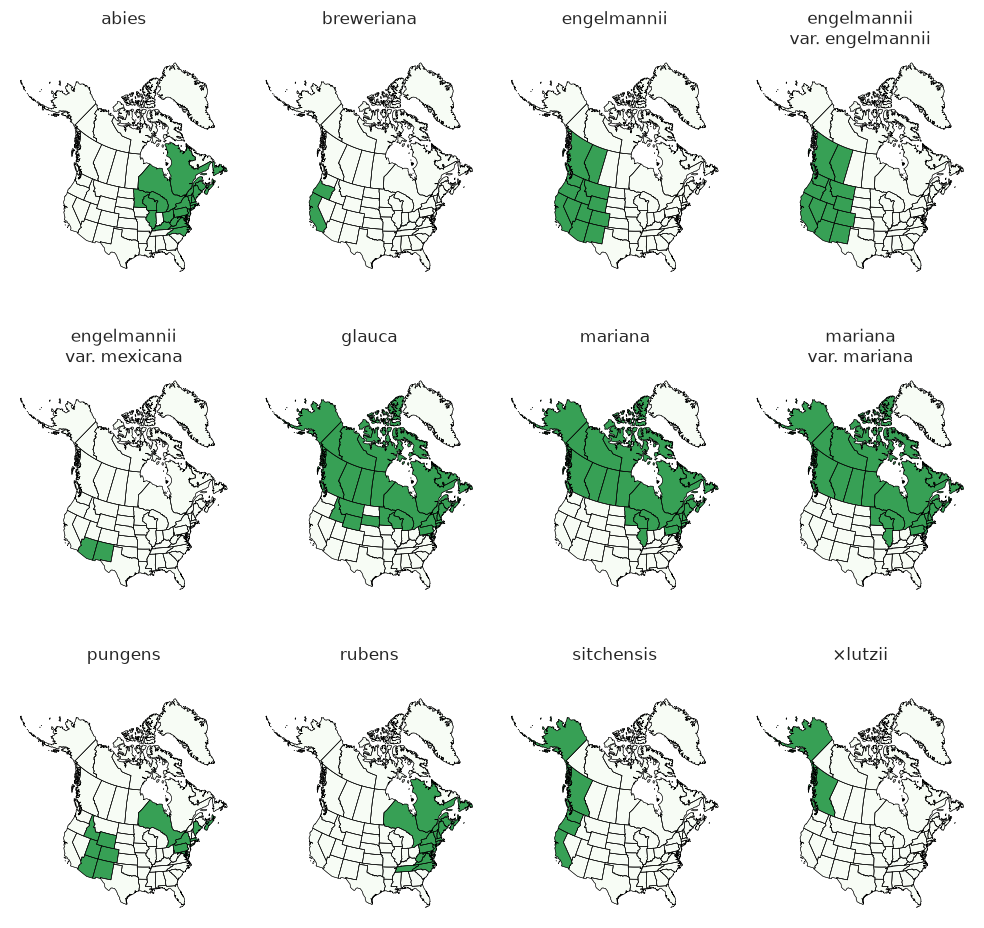

In [31]:
genus_names = genus_occs["taxon"].unique()
per_row = 4
f, axes = plt.subplots(3, per_row)

for ci, species in enumerate(sorted(genus_names)):
    column_occ = "occ_"+species
    locations = genus_occs.loc[genus_occs["taxon"]==species, "location"].unique()
    plants_gdf[column_occ] = 0
    plants_gdf.loc[locations, column_occ] = 1

    pp_occ = {"column": column_occ,
    "cmap": "Greens",
    "palette": seaborn.color_palette("Greens", as_cmap=True),
    "vmin": 0,
    "vmax": 1.5,
    "drop_ids": ["hi", "pr", "vi"]
    }
    lbl = " ".join(species.split()[1:])
    if "var." in lbl:
        lbl = lbl.replace(" var. ", "\nvar. ")
    else:
        lbl += "\n"

    make_plot(plants_gdf, lbl, pp_occ, crs_main,
          legend=False, ax=axes[ci//per_row, ci%per_row]);

f.set_figheight(10)
f.tight_layout()

For most taxa, the occurrence locations form a contiguous area, covering mostly the north (*Picea glauca* and *Picea mariana*), the north-east (*Picea abias* and *Picea rubens*), the west (*Picea engelmannii*), the west coast (*Picea sitchensis*) or even more strictly the southern west coast (*Picea breweriana*).
A notable exception is *Picea pungens*, which is found in two disconnected areas in the north-east and in USA's Interior West.

For illustrative purposes, we show pictures of the main species of spruce occurring in the dataset.

| *Picea abies* | *Picea breweriana* | *Picea engelmannii* | *Picea glauca* |
|:----:|:----:|:----:|:----:|
| Norway spruce | Brewer's spruce | Engelmann spruce | white spruce |
| <a title="The original uploader was MPF at English Wikipedia., CC BY-SA 3.0 &lt;http://creativecommons.org/licenses/by-sa/3.0/&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Picea_abies.jpg"><img width="250" alt="Picea abies" src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/81/Picea_abies.jpg/250px-Picea_abies.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="sheriff_woody_pct, CC BY 4.0 &lt;https://creativecommons.org/licenses/by/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Picea_breweriana,_Paynes_Lake,_Klamath_NF,_Siskiyou,_California_1.jpg"><img width="250" alt="Picea breweriana, Paynes Lake, Klamath NF, Siskiyou, California 1" src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/Picea_breweriana%2C_Paynes_Lake%2C_Klamath_NF%2C_Siskiyou%2C_California_1.jpg/250px-Picea_breweriana%2C_Paynes_Lake%2C_Klamath_NF%2C_Siskiyou%2C_California_1.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="Famartin, CC BY-SA 3.0 &lt;https://creativecommons.org/licenses/by-sa/3.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:2013-07-14_16_58_14_Engelmann_Spruces_just_below_tree-line_along_the_Wheeler_Peak_Summit_Trail.jpg"><img width="250" alt="2013-07-14 16 58 14 Engelmann Spruces just below tree-line along the Wheeler Peak Summit Trail" src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/fb/2013-07-14_16_58_14_Engelmann_Spruces_just_below_tree-line_along_the_Wheeler_Peak_Summit_Trail.jpg/250px-2013-07-14_16_58_14_Engelmann_Spruces_just_below_tree-line_along_the_Wheeler_Peak_Summit_Trail.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="dmcdevit, CC BY-SA 2.0 &lt;https://creativecommons.org/licenses/by-sa/2.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Picea_glauca_in_Denali.jpg"><img width="250" alt="Picea glauca in Denali" src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/Picea_glauca_in_Denali.jpg/250px-Picea_glauca_in_Denali.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> |


|  *Picea ×lutzii* | *Picea mariana* | *Picea pungens* | *Picea sitchensis* |
|:----:|:----:|:----:|:----:|
|  Lutz spruce (hybrid) | black spruce | blue spruce | Stika spruce |
| <a title="a.dombrowski, CC BY-SA 2.0 &lt;https://creativecommons.org/licenses/by-sa/2.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Picea_x_lutzii_Skagway.jpg"><img width="250" alt="Picea x lutzii Skagway" src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5a/Picea_x_lutzii_Skagway.jpg/250px-Picea_x_lutzii_Skagway.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="Daniel Case, CC BY-SA 3.0 &lt;https://creativecommons.org/licenses/by-sa/3.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Black_spruce_stand_at_Arctic_Chalet,_Inuvik,_NT.jpg"><img width="250" alt="Stand of black spruce" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/Black_spruce_stand_at_Arctic_Chalet%2C_Inuvik%2C_NT.jpg/250px-Black_spruce_stand_at_Arctic_Chalet%2C_Inuvik%2C_NT.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="Chris M Morris, CC BY 2.0 &lt;https://creativecommons.org/licenses/by/2.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Blue_Spruce_(15905530369).jpg"><img width="250" alt="Blue Spruce (15905530369)" src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/ad/Blue_Spruce_%2815905530369%29.jpg/250px-Blue_Spruce_%2815905530369%29.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> | <a title="Graaf van Vlaanderen, CC BY-SA 4.0 &lt;https://creativecommons.org/licenses/by-sa/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Sitka_01.JPG"><img width="250" alt="Picea sitchensis (Sitka spruce)" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/48/Sitka_01.JPG/250px-Sitka_01.JPG?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a> |

Source: [Wikimedia Commons](commons.wikimedia.org/wiki/Category:Picea)